## Colab Mount Drive

In [ ]:
# prompt: mount drive

from google.colab import drive
drive.mount('/content/drive')


## Set Main Pathes

In [7]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False



In [8]:
import platform

if platform.system() == "Linux":
    if is_colab():
      print("Running in Google Colab")
      path_main_folder = "/content/drive/My Drive/study/graduation_project/final/Code/project_files/TrafficManager/"
    else:
      print("Not running in HPC Linux (default linux)")
      path_main_folder = ""

else:
    print("Running on Windows")
    path_main_folder = "I:/My Drive/study/graduation_project/final/Code/project_files/TrafficManager/"

path_data_folder = path_main_folder+"TrafficManager/AIST_Cleaned/data1_tomart/"#data2_mosheerIsmail
path_data_file = path_data_folder + "cfg.sumocfg"
path_project_folder = path_main_folder +"old_project/"

sumo_binary ="C:/Program Files (x86)/Eclipse/Sumo/bin/sumo.exe" #"C:/Program Files (x86)/Eclipse/Sumo/bin/sumo-gui.exe" if windows ,if colab : "/usr/share/sumo/bin/sumo"
sumo_home ="C:/Program Files (x86)/Eclipse/Sumo" #"C:/Program Files (x86)/Eclipse/Sumo" if windows ,if colab :  "/usr/share/sumo"



Running on Windows


In [9]:
cmd = [sumo_binary, "-c" , path_data_file ]


In [10]:
# prompt: check if file path ok

import os

if os.path.exists(path_main_folder):
  print(f"File exists at: {path_main_folder}")
else:
  print(f"File does not exist at: {path_main_folder}")


File exists at: I:/My Drive/study/graduation_project/final/Code/project_files/TrafficManager/


## Modifible Parameters

In [1]:
max_steps = 4000
scenario = 'aist'
re = "2" # 2 : second-project ,3 proposed ,4 literateure
action_type = "Full" #"High" , "Grouped" ,"Full"
precent_scale = .14 # .14 normal or .38 for large scale
seed = 1


tl_id = '1888496828' #'1698478721' for data2 , '1888496828' for data 1 , '6082411793' for data 3 

count_lns = 17 #17

In [2]:
traffic_lights = [(count_lns, tl_id)]
clusters_2 = [(1, [tl_id],count_lns)]
sumo_Scale = int(10 * precent_scale )

### Install Sumo

In [3]:
!sudo add-apt-repository -y ppa:sumo/stable
!sudo apt-get update
!sudo apt-get install -y sumo sumo-tools sumo-doc


'sudo' is not recognized as an internal or external command,
operable program or batch file.
'sudo' is not recognized as an internal or external command,
operable program or batch file.
'sudo' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
!source ~/.bashrc


'source' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
!sumo --version


Eclipse SUMO sumo Version 1.21.0
 Build features: Windows-10.0.17763 AMD64 MSVC 19.29.30133.0 Release FMI Proj GUI Intl SWIG Eigen
 Copyright (C) 2001-2024 German Aerospace Center (DLR) and others; https://sumo.dlr.de

Eclipse SUMO sumo Version 1.21.0 is part of SUMO.
This program and the accompanying materials
are made available under the terms of the Eclipse Public License v2.0
which accompanies this distribution, and is available at
http://www.eclipse.org/legal/epl-v20.html
This program may also be made available under the following Secondary
Licenses when the conditions for such availability set forth in the Eclipse
Public License 2.0 are satisfied: GNU General Public License, version 2
or later which is available at
https://www.gnu.org/licenses/old-licenses/gpl-2.0-standalone.html
SPDX-License-Identifier: EPL-2.0 OR GPL-2.0-or-later


## Install Packages

In [ ]:
!pip install traci
!pip install colorama
!pip install optuna


## Import Packages

In [11]:
import sys
sys.path.append(path_project_folder)

In [12]:
from sumoEnv import SumoEnv
from agent import Agent, FullDqnAgent
from rewardfn import *
import pandas as pd
import ast
import argparse
import json
from theParser import dqnParse
import time

## Set algorithm

In [13]:
cluster = 'clusters_maxabs_3dimensions'

#traffic_light_counts_to_include =  [1 ,2 ,3 ,4]

use_full_dqn = True

if re == "1":
    reward_function = firstRewardFunction
elif re == "2":
    reward_function = secondRewardFunction
elif re == "3":
    reward_function = reward_proposed
else:
    reward_function = reward_liter

In [14]:
class config():
    def __init__(self, sumoBinary, sumoCmd, sumo_home=None):
        self.sumoBinary = sumoBinary
        self.sumoCmd = sumoCmd
        self.sumo_home = sumo_home

In [15]:
sumo_gui = config(sumo_binary,cmd,sumo_home)
env = SumoEnv(sumo_gui, traffic_lights, reward_function,action_type,seed)


In [16]:
traci.simulation.setScale(sumo_Scale)

In [17]:

agent_infos = []
for (cluster_id, tl_ids, count) in clusters_2:# i think cluster_id, tl_ids, count not used,just used tl_ids as expected

    stateCount = env.stateCount(tl_ids[0])
    actionCount = env.actionCount(tl_ids[0])
    iniStates = []
    for i in range(len(tl_ids)):
        iniStates.append(env.emptyState(tl_ids[0]))
    if use_full_dqn:
        new_agent = FullDqnAgent(tl_ids[0],stateCount, actionCount)
    else:
        new_agent = Agent(tl_ids[0],stateCount, actionCount)
    agent_infos.append([new_agent, tl_ids, iniStates, None])



c:\Users\LapStore\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
import subprocess
import os

def get_sumo_statics(python_path, data_path):
    # Construct the paths using os.path.join (automatically handles path separator)
    script_path = os.path.join(python_path, 'tools', 'xml', 'xml2csv.py')
    data_file_path = os.path.join(data_path, "osm.statistics.xml")

    # Determine the correct Python executable based on the OS
    python_executable = 'python' if os.name == 'nt' else 'python3'  # 'nt' is for Windows

    # Check if the script exists before running
    if not os.path.exists(script_path):
        print(f"Error: Script not found at {script_path}")
        return
    
    # Prepare the command to run the script
    command = [python_executable, script_path, data_file_path]

    # Run the script using subprocess
    try:
        subprocess.run(command, check=True)
        print(f"Successfully ran {script_path} with {data_file_path}")
    except subprocess.CalledProcessError as e:
        print(f"An error occurred: {e}")
    except FileNotFoundError:
        print(f"File not found: {script_path}")

    data = pd.read_csv(os.path.join(data_path, "osm.statistics.csv"), delimiter=';')

    Values_dict = dict({
        'Waiting_Time':float(data['vehicleTripStatistics_waitingTime'].dropna().iloc[0]) ,
        'Speed':float(data['vehicleTripStatistics_speed'].dropna().iloc[0])   ,
        'Waiting_Vehicles':float(data['vehicles_waiting'].dropna().iloc[0])   ,
        'TimeLoss':float(data['vehicleTripStatistics_timeLoss'].dropna().iloc[0])   ,
        'Depart_Delay':float(data['vehicleTripStatistics_departDelay'].dropna().iloc[0])   ,  

    })
    return Values_dict


## Begin training

In [19]:
import tensorflow as tf
tf.keras.utils.disable_interactive_logging()


In [20]:
time_before =time.time()
rewards = []

steps = 0

while True:
    sim_time = traci.simulation.getTime()
    if (sim_time) % 50 == 0:
        print("Simulation time: ", sim_time)
    #    add_traffic(tl_id, n_scale)
    for agent_info in agent_infos:
        agent = agent_info[0]
        tl_id_list = agent_info[1]
        state_list = agent_info[2]
        action_list = []

        for i, tl_id in enumerate(tl_id_list):
            action = agent.act(state_list[i])
            env.setAction(action, tl_id)
            action_list.append(action)

        agent_info[3] = action_list

    steps += 1

    env.step()


    for agent_info in agent_infos:
        agent = agent_info[0]
        tl_id_list = agent_info[1]
        state_list = agent_info[2]
        action_list = agent_info[3]
        new_state_list = []
        for i, tl_id in enumerate(tl_id_list):
            s = state_list[i]
            a = action_list[i]
            s_, r, done, info = env.actionResults(tl_id)
            rewards.append(r)
            agent.observe((s, a, r, s_))
            agent.replay()
            new_state_list.append(s_)
        agent_info[2] = new_state_list

    if done:
        s_ = None

    if steps == max_steps:
        #env.close()
        break

    if done:
        break


time_after = time.time()

Simulation time:  3550.0
Simulation time:  3600.0
Simulation time:  3650.0
Simulation time:  3700.0
Simulation time:  3750.0
Simulation time:  3800.0
Simulation time:  3850.0
Simulation time:  3900.0
Simulation time:  3950.0


In [21]:
def append_to_file(filename, text):
    with open(filename, 'a') as file:
        file.write(text + '\n')  # '\n' لتضيف السطر الجديد بعد كل جملة


In [25]:
from colorama import Fore, Style

time_diff = time_after - time_before
print(Fore.GREEN + f"Time taken for training: {round(time_diff,3)} seconds ({round(time_diff/60,3)} Minutes)" + Style.RESET_ALL)


Time taken for training: 2363.827 seconds (39.397 Minutes)


In [23]:
print(Fore.MAGENTA + f"The Cumulative Reward of the Epsiode is : {round(sum(rewards),3)} ,Using Reward {re} " + Style.RESET_ALL)


The Cumulative Reward of the Epsiode is : -1562.152 ,Using Reward 2 


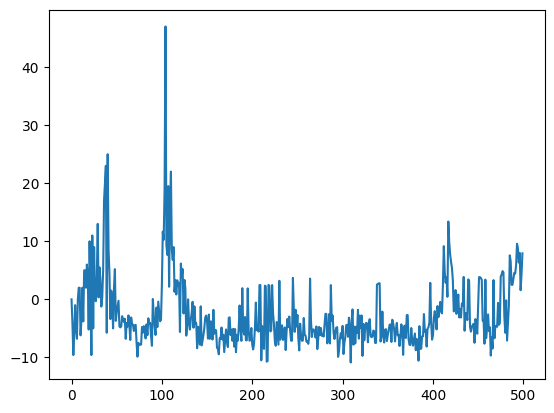

In [23]:
import matplotlib.pyplot as plt
plt.plot(rewards)
plt.show()

In [24]:
traci.close()
get_sumo_statics(sumo_home,path_data_folder)


Successfully ran C:/Program Files (x86)/Eclipse/Sumo\tools\xml\xml2csv.py with I:/My Drive/study/graduation_project/final/Code/project_files/TrafficManager/TrafficManager/AIST_Cleaned/data1_tomart/osm.statistics.xml


{'Waiting_Time': 78.56,
 'Speed': 3.99,
 'Waiting_Vehicles': 2245.0,
 'TimeLoss': 189.65,
 'Depart_Delay': 683.57}

In [25]:
dict=get_sumo_statics(sumo_home,path_data_folder)


Successfully ran C:/Program Files (x86)/Eclipse/Sumo\tools\xml\xml2csv.py with I:/My Drive/study/graduation_project/final/Code/project_files/TrafficManager/TrafficManager/AIST_Cleaned/rl_training/osm.statistics.xml


In [27]:
for key, value in dict.items():
    append_to_file("output2.txt",f"{key}: {round(value,3)}" )


In [ ]:
traci.close()